C:\Users\asmaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Silhouette Score: 0.6520417462411836


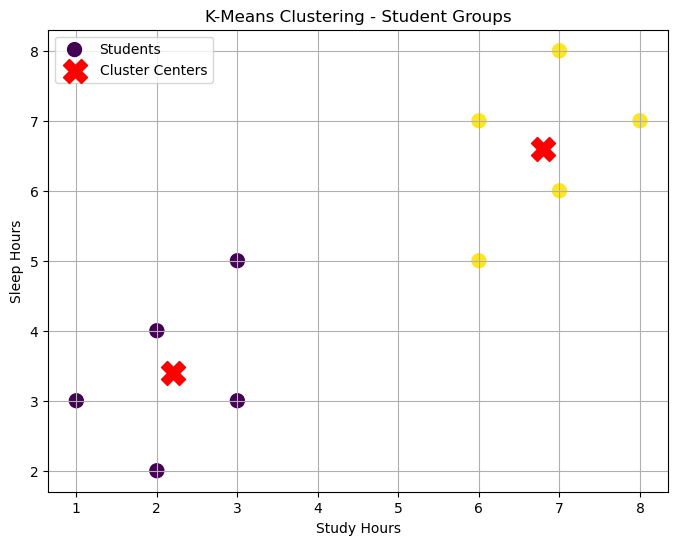

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. بيانات واقعية (بدون تصنيف)
data = pd.DataFrame({
    'Study_Hours': [2, 3, 1, 2, 3, 6, 7, 8, 6, 7],
    'Sleep_Hours': [4, 5, 3, 2, 3, 7, 6, 7, 5, 8]
})

X = data[['Study_Hours', 'Sleep_Hours']]

# 2. إنشاء نموذج K-Means بعدد مجموعات 2 (مثلاً: طلاب نشيطين / طلاب غير نشيطين)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

# 3. إضافة نتائج التجميع إلى الجدول
data['Cluster'] = kmeans.labels_

# 4. تقييم النموذج باستخدام Silhouette Score
sil_score = silhouette_score(X, kmeans.labels_)
print("Silhouette Score:", sil_score)

# 5. رسم التكتلات والمراكز
plt.figure(figsize=(8,6))
plt.scatter(X['Study_Hours'], X['Sleep_Hours'], c=data['Cluster'], cmap='viridis', s=100, label='Students')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', s=300, marker='X', label='Cluster Centers')

plt.title("K-Means Clustering - Student Groups")
plt.xlabel("Study Hours")
plt.ylabel("Sleep Hours")
plt.legend()
plt.grid(True)
plt.show()
